# TA-XLM-R 
## Key Improvements over v3:
- **Mean-pooling over all tokens** (not just CLS) — captures richer sequence context
- **Char CNN** replaces BiLSTM — faster, better local n-gram features
- **Larger char hidden dim** (256 → 384) — better representational capacity
- **Unfreeze top 6 layers** (was top 4) — more XLM-R fine-tuning
- **Separate LR groups**: embeddings frozen, lower layers 1e-5, upper layers 2e-5, head 1e-4
- **Gradient accumulation** (steps=4) → effective batch 64 without OOM
- **Mixup augmentation** on embeddings — improves generalization
- **Label smoothing via CrossEntropy** (cleaner than combined with Focal)
- **Longer max_len=160** — captures more context
- **Warmup 15%** of steps (was 10%)
- **SWA (Stochastic Weight Averaging)** — smooths loss landscape
- **Expanded transliteration map** — better normalization coverage

## 1. Install & Import

In [1]:
import subprocess, sys
import torch
print(f'Current torch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

!pip install torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu118 -q
!pip install transformers==4.40.0 scikit-learn pandas numpy matplotlib seaborn -q
print('\nInstallation complete. RESTART KERNEL if first run, then re-run from cell 2.')

Current torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0+cu118, 2.2.1+cu118, 2.2.2+cu118, 2.3.0+cu118, 2.3.1+cu118, 2.4.0+cu118, 2.4.1+cu118, 2.5.0+cu118, 2.5.1+cu118, 2.6.0+cu118, 2.7.0+cu118, 2.7.1+cu118)
ERROR: No matching distribution found for torch==2.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.

Installation complet

In [2]:
import os, re, json, random, copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

matplotlib.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# ── CUDA Safety ──────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    try:
        _t = torch.zeros(2, 2).cuda()
        _t2 = torch.nn.LSTM(2, 2).cuda()
        del _t, _t2
        DEVICE = torch.device('cuda')
        print(f'CUDA OK — GPU: {torch.cuda.get_device_name(0)}')
    except Exception as e:
        print(f'CUDA test failed: {e}. Falling back to CPU.')
        DEVICE = torch.device('cpu')
else:
    DEVICE = torch.device('cpu')
    print('CUDA not available — using CPU.')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

# ── Config ───────────────────────────────────────────────────────────────────
CFG = {
    'xlmr_model'     : 'xlm-roberta-base',
    'max_len'        : 160,          # ↑ from 128 — more context captured
    'batch_size'     : 16,
    'grad_accum'     : 4,            # NEW: effective batch = 64
    'lr_embed'       : 0.0,          # frozen
    'lr_lower'       : 1e-5,         # NEW: layers 0-5 — very slow
    'lr_upper'       : 2e-5,         # layers 6-11 — moderate
    'lr_head'        : 1e-4,         # NEW: classifier head — fast
    'epochs'         : 30,
    'patience'       : 6,            # ↑ from 5
    'dropout'        : 0.2,          # ↓ from 0.3 — less regularization needed
    'char_emb_dim'   : 64,
    'char_out_dim'   : 384,          # ↑ from 256
    'num_heads'      : 8,            # ↑ from 4
    'num_classes'    : 4,
    'label_smoothing': 0.1,
    'mixup_alpha'    : 0.2,          # NEW: mixup augmentation
    'warmup_ratio'   : 0.15,         # ↑ from 0.10
    'test_size'      : 0.15,
    'val_size'       : 0.15,
    'seeds'          : [42, 123, 7],
    'swa_start_frac' : 0.75,         # NEW: SWA starts at 75% of training
    'swa_lr'         : 5e-6,         # NEW: SWA learning rate
    'unfreeze_from_layer': 6,        # ↑ from 8 — fine-tune more layers
}

LABEL2ID = {
    'Literary Appreciation': 0,
    'Analytical Reflection': 1,
    'Constructive Critique': 2,
    'Strong Critique'      : 3,
}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
SHORT_LBL = ['Lit. App.', 'Anal. Ref.', 'Cons. Crit.', 'Str. Crit.']
print('Configuration ready.')

CUDA OK — GPU: Tesla T4
Device: cuda | PyTorch: 2.10.0+cu128
Configuration ready.


## 2. Load Dataset

In [3]:
print('Scanning /kaggle/input ...')
found_files = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full = os.path.join(root, f)
        found_files.append(full)
        print(full)

dataset_path = found_files[0] if found_files else None
print(f'\nUsing: {dataset_path}')

Scanning /kaggle/input ...
/kaggle/input/datasets/rafsanpronoy/bbbrc-dataset-banglabanglish-book-review-corpus/sampled_book_reviews.csv
/kaggle/input/datasets/rafsanpronoy/bbbrc-dataset-banglabanglish-book-review-corpus/sampled_book_reviews.xlsx

Using: /kaggle/input/datasets/rafsanpronoy/bbbrc-dataset-banglabanglish-book-review-corpus/sampled_book_reviews.csv


In [4]:
df_raw = pd.read_csv(dataset_path)
print(f'Raw shape: {df_raw.shape}')
print(df_raw.head(3))
print('Columns:', df_raw.columns.tolist())

Raw shape: (25318, 3)
   ID                                               Text  \
0   1  Unar boita Rokomari te dekhlei modulus operato...   
1   2   Jabaner hefajot onek guruttopurno ekta bishoy...   
2   3            এই বইটি ইতিহাসের পিছনে ইতিহাস দেখায় ..   

                   Label  
0  Analytical Reflection  
1  Analytical Reflection  
2  Literary Appreciation  
Columns: ['ID', 'Text', 'Label']


In [5]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
text_col  = next(c for c in df.columns if c.lower() == 'text')
label_col = next(c for c in df.columns if c.lower() == 'label')

df['text']  = df[text_col].astype(str).str.strip()
df['label'] = df[label_col].str.strip().map(LABEL2ID)
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

def detect_script(text):
    bangla_chars = len(re.findall(r'[\u0980-\u09FF]', text))
    latin_chars  = len(re.findall(r'[a-zA-Z]', text))
    if bangla_chars > latin_chars: return 'Bangla'
    elif latin_chars > bangla_chars: return 'Banglish'
    return 'Mixed'

df['script'] = df['text'].apply(detect_script)
print(f'Total: {len(df)}')
print('Label dist:', df['label'].value_counts().to_dict())
print('Script dist:', df['script'].value_counts().to_dict())

Total: 25318
Label dist: {0: 17954, 1: 4930, 2: 1612, 3: 822}
Script dist: {'Bangla': 12629, 'Banglish': 12619, 'Mixed': 70}


## 3. Expanded Transliteration Normalization

In [6]:
# ── Expanded transliteration map (v4: +20 new entries) ───────────────────────
TRANSLITERATION_MAP = {
    # 'good' variants
    r'\bvalo\b'        : 'bhalo',
    r'\bbhaalo\b'      : 'bhalo',
    r'\bvhalo\b'       : 'bhalo',
    r'\bvhala\b'       : 'bhala',
    r'\bvala\b'        : 'bhala',
    r'\bbhallow\b'     : 'bhalo',    # NEW
    r'\bbhalo\b'       : 'bhalo',
    # 'very' variants
    r'\bkub\b'         : 'khub',
    r'\bkhoob\b'       : 'khub',
    r'\bkhob\b'        : 'khub',
    r'\bkhub\b'        : 'khub',
    r'\bkhubi\b'       : 'khubi',    # NEW
    # sentiment
    r'\bbajey\b'       : 'baje',
    r'\bbaajey\b'      : 'baje',
    r'\boshadharan\b'  : 'oshadharon',
    r'\boshaadharon\b' : 'oshadharon',
    r'\bosadharon\b'   : 'oshadharon',   # NEW
    r'\bosadharan\b'   : 'oshadharon',   # NEW
    r'\bdarun\b'       : 'darun',        # NEW
    r'\bdaaroon\b'     : 'darun',        # NEW
    r'\bdharoon\b'     : 'darun',        # NEW
    r'\bharidam\b'     : 'haridam',      # NEW: 'terrible'
    r'\bmojar\b'       : 'mojar',        # NEW: 'fun'
    r'\bmojar\b'       : 'mojar',
    r'\bmojaar\b'      : 'mojar',        # NEW
    r'\bshundhor\b'    : 'shundor',
    r'\bsundor\b'      : 'shundor',
    r'\bsundhor\b'     : 'shundor',      # NEW
    # verbs
    r'\blageche\b'     : 'lagche',
    r'\blagechhe\b'    : 'lagche',
    r'\bhoyechhe\b'    : 'hoyeche',
    r'\bkorchhi\b'     : 'korchi',
    r'\bkorchhe\b'     : 'korche',       # NEW
    r'\bdekhechhi\b'   : 'dekhechi',     # NEW
    r'\bporechi\b'     : 'porechi',
    r'\bporechhi\b'    : 'porechi',
    r'\bparhchi\b'     : 'porchi',       # NEW: 'reading'
    r'\bparchhi\b'     : 'porchi',       # NEW
    # misc
    r'\bkharaap\b'     : 'kharap',
    r'\bkinto\b'       : 'kintu',
    r'\bvoyanok\b'     : 'bhayanok',
    r'\bvoalo\b'       : 'bhalo',
    r'\bbekar\b'       : 'bekar',        # already normalized
    r'\bbekaar\b'      : 'bekar',        # NEW
    r'\bnirashajonok\b': 'nirashajanak', # NEW: 'disappointing'
    r'\bniraasha\b'    : 'nirasha',      # NEW
    r'\bokkhom\b'      : 'okkham',       # NEW: 'incapable'
    r'\bprosongshanio\b': 'prasangshaniyo', # NEW: 'praiseworthy'
    r'\bprosongsha\b'  : 'prasangsha',   # NEW
    r'\banuvab\b'      : 'anubhav',      # NEW: 'experience'
    r'\bonubhob\b'     : 'anubhav',      # NEW
    r'\bonuvob\b'      : 'anubhav',      # NEW
}

def normalize_transliteration(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    # Keep Bangla Unicode + basic punctuation
    text = re.sub(r'[^\w\s\u0980-\u09FF!?.,।]', ' ', text)
    for pattern, replacement in TRANSLITERATION_MAP.items():
        text = re.sub(pattern, replacement, text)
    return text.strip()

df['text_norm'] = df['text'].apply(normalize_transliteration)
print(f'Normalization complete. Sample:')
print(df[['text', 'text_norm']].head(3))

Normalization complete. Sample:
                                                text  \
0  Unar boita Rokomari te dekhlei modulus operato...   
1   Jabaner hefajot onek guruttopurno ekta bishoy...   
2            এই বইটি ইতিহাসের পিছনে ইতিহাস দেখায় ..   

                                           text_norm  
0  unar boita rokomari te dekhlei modulus operato...  
1   jabaner hefajot onek guruttopurno ekta bishoy...  
2            এই বইটি ইতিহাসের পিছনে ইতিহাস দেখায় ..  


## 4. Character Vocabulary

In [7]:
def build_char_vocab(texts, max_chars=400):    # ↑ from 350
    counter = Counter(ch for t in texts for ch in t)
    vocab   = {'<PAD>': 0, '<UNK>': 1}
    for ch, _ in counter.most_common(max_chars):
        vocab[ch] = len(vocab)
    return vocab

def text_to_char_ids(text, vocab, max_len=160):
    ids = [vocab.get(ch, vocab['<UNK>']) for ch in text[:max_len]]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

CHAR_VOCAB = build_char_vocab(df['text_norm'].tolist())
print(f'Char vocab size: {len(CHAR_VOCAB)}')

Char vocab size: 161


## 5. Dataset & DataLoader

In [8]:
TOKENIZER = AutoTokenizer.from_pretrained(CFG['xlmr_model'])

class BanglaDataset(Dataset):
    def __init__(self, dataframe, tokenizer, char_vocab, max_len):
        self.texts      = dataframe['text_norm'].tolist()
        self.labels     = dataframe['label'].tolist()
        self.tokenizer  = tokenizer
        self.char_vocab = char_vocab
        self.max_len    = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]
        enc   = self.tokenizer(
            text, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        char_ids = torch.tensor(
            text_to_char_ids(text, self.char_vocab, self.max_len),
            dtype=torch.long
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'char_ids'       : char_ids,
            'label'          : torch.tensor(label, dtype=torch.long),
        }

def make_loader(df_split, shuffle=False):
    ds = BanglaDataset(df_split, TOKENIZER, CHAR_VOCAB, CFG['max_len'])
    return DataLoader(ds, batch_size=CFG['batch_size'],
                      shuffle=shuffle, num_workers=0, pin_memory=True)

print('Dataset class ready.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset class ready.


## 6. TA-XLM-R v4 Architecture
### Key improvements: Char CNN, Mean-pooling, Larger fusion, Better LR groups

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  Character CNN Encoder (replaces BiLSTM — better local n-gram features)
# ─────────────────────────────────────────────────────────────────────────────
class CharCNNEncoder(nn.Module):
    """
    Multi-scale char CNN: captures 2,3,4-gram character patterns.
    Output dim = out_dim (via projection).
    """
    def __init__(self, vocab_size, emb_dim, out_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        # Three parallel convolutions with different kernel sizes
        num_filters = out_dim // 3
        self.conv2 = nn.Conv1d(emb_dim, num_filters, kernel_size=2, padding=1)
        self.conv3 = nn.Conv1d(emb_dim, num_filters, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(emb_dim, num_filters, kernel_size=4, padding=2)
        cnn_out = num_filters * 3
        self.proj = nn.Linear(cnn_out, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, char_ids):
        x = self.dropout(self.embedding(char_ids))   # (B, L, emb)
        x = x.transpose(1, 2)                        # (B, emb, L)
        c2 = F.relu(self.conv2(x)).max(dim=-1)[0]    # (B, filters)
        c3 = F.relu(self.conv3(x)).max(dim=-1)[0]
        c4 = F.relu(self.conv4(x)).max(dim=-1)[0]
        cat = torch.cat([c2, c3, c4], dim=-1)        # (B, 3*filters)
        return self.norm(self.proj(cat))              # (B, out_dim)


# ─────────────────────────────────────────────────────────────────────────────
#  Cross-Modal Attention Fusion
#  XLM-R mean-pool (768) + Char CNN (384) → cross-attention → (768+384=1152)
# ─────────────────────────────────────────────────────────────────────────────
class CrossModalFusion(nn.Module):
    """
    Uses XLM-R features to attend over Char features and vice versa,
    then concatenates and applies residual + LayerNorm.
    """
    def __init__(self, xlmr_dim, char_dim, num_heads, dropout):
        super().__init__()
        fused_dim = xlmr_dim + char_dim
        # Cross-attention: XLM-R queries char
        self.xlmr_proj = nn.Linear(xlmr_dim, xlmr_dim)
        self.char_proj  = nn.Linear(char_dim,  char_dim)
        # Project to common dim for MHA
        common = min(xlmr_dim, char_dim)
        self.to_common_x = nn.Linear(xlmr_dim, common)
        self.to_common_c = nn.Linear(char_dim,  common)
        self.mha = nn.MultiheadAttention(
            embed_dim=common, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.from_common = nn.Linear(common, xlmr_dim)
        self.norm = nn.LayerNorm(fused_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, xlmr_vec, char_vec):
        # Project
        xp = self.xlmr_proj(xlmr_vec).unsqueeze(1)   # (B, 1, xlmr_dim)
        cp = self.char_proj(char_vec).unsqueeze(1)    # (B, 1, char_dim)
        # Cross-attention in common space
        xc = self.to_common_x(xp)   # (B, 1, common)
        cc = self.to_common_c(cp)   # (B, 1, common)
        attn_out, _ = self.mha(xc, cc, cc)           # XLM-R queries char
        attn_out = self.dropout(self.from_common(attn_out)).squeeze(1)  # (B, xlmr_dim)
        # Residual xlmr + attended, concat with char
        xlmr_enhanced = xlmr_vec + attn_out          # (B, xlmr_dim)
        fused = torch.cat([xlmr_enhanced, char_vec], dim=-1)  # (B, fused)
        return self.norm(fused)


# ─────────────────────────────────────────────────────────────────────────────
#  TA-XLM-R v4 — Full Model
# ─────────────────────────────────────────────────────────────────────────────
class TAXLMRobertaV4(nn.Module):
    """
    TA-XLM-R v4 Architecture
    ────────────────────────────────────────────────────────────
    Input → XLM-RoBERTa mean-pool (768) ─────────────┐
    Input → Char CNN (384) ──────────────────────────┤
                              Cross-Modal Attention Fusion
                              + Residual + LayerNorm (1152)
                                     ↓
                              Dense 512 → GELU → Dropout
                                     ↓
                              Softmax (4 classes)

    Improvements:
    - Mean-pooling over all tokens (not just CLS)
    - Char CNN (multi-scale) replaces BiLSTM
    - Cross-modal attention (XLM-R ↔ Char)
    - GELU activation (smoother than ReLU)
    """
    def __init__(self, cfg, char_vocab_size):
        super().__init__()
        self.xlmr = AutoModel.from_pretrained(cfg['xlmr_model'])
        self.char_encoder = CharCNNEncoder(
            vocab_size=char_vocab_size,
            emb_dim=cfg['char_emb_dim'],
            out_dim=cfg['char_out_dim'],
            dropout=cfg['dropout']
        )
        xlmr_dim  = 768
        char_dim  = cfg['char_out_dim']   # 384
        fused_dim = xlmr_dim + char_dim   # 1152
        self.fusion = CrossModalFusion(
            xlmr_dim=xlmr_dim,
            char_dim=char_dim,
            num_heads=cfg['num_heads'],
            dropout=cfg['dropout']
        )
        self.dropout = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.GELU(),                   # ↑ smoother than ReLU
            nn.Dropout(cfg['dropout']),
            nn.Linear(512, cfg['num_classes'])
        )
        self._fused_dim = fused_dim

    def encode(self, input_ids, attention_mask, char_ids):
        """Returns fused embedding (for mixup)."""
        xlmr_out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        # Mean-pool over non-padding tokens (better than CLS only)
        mask_exp  = attention_mask.unsqueeze(-1).float()
        mean_pool = (xlmr_out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        cls_pool  = xlmr_out.last_hidden_state[:, 0, :]   # CLS
        # Combine CLS + mean-pool (richer representation)
        xlmr_vec  = self.dropout((mean_pool + cls_pool) / 2)
        char_vec  = self.dropout(self.char_encoder(char_ids))
        return self.fusion(xlmr_vec, char_vec)

    def forward(self, input_ids, attention_mask, char_ids, fused=None):
        if fused is None:
            fused = self.encode(input_ids, attention_mask, char_ids)
        return self.classifier(fused)


# ─── XLM-R-only baseline ─────────────────────────────────────────────────────
class XLMROnly(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.xlmr       = AutoModel.from_pretrained(cfg['xlmr_model'])
        self.dropout    = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Linear(768, cfg['num_classes'])

    def forward(self, input_ids, attention_mask, char_ids, fused=None):
        out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(cls)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

try:
    _ta = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    _b  = XLMROnly(CFG).to(DEVICE)
    print(f'XLM-R-only   params: {count_params(_b):>12,}')
    print(f'TA-XLM-R v4  params: {count_params(_ta):>12,}')
    del _ta, _b
    print(f'Model instantiation on {DEVICE} — SUCCESS')
except RuntimeError as e:
    print(f'GPU failed: {e}. Switching to CPU.')
    DEVICE = torch.device('cpu')
    _ta = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    print(f'TA-XLM-R v4  params: {count_params(_ta):>12,}')
    del _ta

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

XLM-R-only   params:  278,046,724
TA-XLM-R v4  params:  280,939,972
Model instantiation on cuda — SUCCESS


## 7. Mixup Augmentation & Loss

In [10]:
def mixup_batch(fused_emb, labels, alpha=0.2, num_classes=4):
    """
    Mixup in embedding space. Returns mixed embeddings and soft labels.
    Applied during training only.
    """
    if alpha <= 0:
        oh = F.one_hot(labels, num_classes).float()
        return fused_emb, oh
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(fused_emb.size(0), device=fused_emb.device)
    mixed = lam * fused_emb + (1 - lam) * fused_emb[idx]
    oh_a  = F.one_hot(labels, num_classes).float()
    oh_b  = F.one_hot(labels[idx], num_classes).float()
    soft_labels = lam * oh_a + (1 - lam) * oh_b
    return mixed, soft_labels


class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing and optional class weights."""
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight   # (num_classes,) tensor or None

    def forward(self, logits, soft_labels):
        """
        logits     : (B, C) raw logits
        soft_labels: (B, C) soft one-hot (from mixup or pure one-hot)
        """
        num_classes = logits.size(-1)
        log_p = F.log_softmax(logits, dim=-1)
        # Apply additional label smoothing on top of soft labels
        smooth = soft_labels * (1 - self.smoothing) + self.smoothing / num_classes
        loss = -(smooth * log_p).sum(dim=-1)   # (B,)
        if self.weight is not None:
            # Weight by predicted class (approx: weight of true class)
            hard_labels = soft_labels.argmax(dim=-1)
            w = self.weight[hard_labels]
            loss = loss * w
        return loss.mean()


print('Mixup & LabelSmoothingCrossEntropy ready.')

Mixup & LabelSmoothingCrossEntropy ready.


## 8. Training Utilities with SWA & Early Stopping

In [11]:
# ============================================================================
# CELL 19 (corrected) — Training Utilities with SWA & Early Stopping
# ============================================================================

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def compute_all_metrics(y_true, y_pred):
    return {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'macro_f1'   : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa'      : cohen_kappa_score(y_true, y_pred),
    }


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None,
              use_mixup=False, grad_accum=1):
    """One training or eval epoch. Returns (loss, acc, macro_f1, y_true, y_pred)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    if is_train and optimizer:
        optimizer.zero_grad()

    with ctx:
        for step, batch in enumerate(loader):
            iids = batch['input_ids'].to(DEVICE)
            amsk = batch['attention_mask'].to(DEVICE)
            cids = batch['char_ids'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)

            if is_train and use_mixup and hasattr(model, 'encode'):
                fused = model.encode(iids, amsk, cids)
                mixed_fused, soft_lbls = mixup_batch(
                    fused, lbls, alpha=CFG['mixup_alpha'],
                    num_classes=CFG['num_classes']
                )
                logits = model(None, None, None, fused=mixed_fused)
                loss   = criterion(logits, soft_lbls)
                with torch.no_grad():
                    hard_logits = model(None, None, None, fused=fused)
                all_preds.extend(hard_logits.argmax(-1).cpu().numpy())
            else:
                # FIX: AveragedModel (SWA) does not expose `.encode`, so this
                # branch is also taken for swa_model — `model(iids, amsk, cids)`
                # forwards correctly through AveragedModel.forward -> module.forward
                logits = model(iids, amsk, cids)
                oh     = F.one_hot(lbls, CFG['num_classes']).float()
                loss   = criterion(logits, oh)
                all_preds.extend(logits.argmax(-1).cpu().numpy())

            all_labels.extend(lbls.cpu().numpy())

            if is_train:
                (loss / grad_accum).backward()
                if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    if scheduler: scheduler.step()
                    optimizer.zero_grad()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    mf1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, mf1, all_labels, all_preds


class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None
        self.best_epoch = 0
        self.stopped_epoch = 0

    def step(self, score, model, epoch):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch          # FIX: track which epoch was best
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True
        return False


def build_optimizer(model, cfg):
    freeze_from = cfg['unfreeze_from_layer']
    if hasattr(model, 'xlmr'):
        for name, param in model.xlmr.named_parameters():
            if 'embeddings' in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        lower_params, upper_params = [], []
        for name, param in model.xlmr.named_parameters():
            if not param.requires_grad: continue
            if 'encoder.layer' in name:
                ln = int(name.split('encoder.layer.')[1].split('.')[0])
                if ln < freeze_from:
                    lower_params.append(param)
                else:
                    upper_params.append(param)
            else:
                upper_params.append(param)

        head_params = [p for n, p in model.named_parameters()
                       if not n.startswith('xlmr') and p.requires_grad]

        param_groups = [
            {'params': lower_params, 'lr': cfg['lr_lower']},
            {'params': upper_params, 'lr': cfg['lr_upper']},
            {'params': head_params,  'lr': cfg['lr_head']},
        ]
    else:
        param_groups = [{'params': model.parameters(), 'lr': cfg['lr_upper']}]

    return AdamW(param_groups, weight_decay=1e-2)


def train_model(model, train_loader, val_loader, cfg, verbose=True):
    """
    Full training loop with SWA + early stopping.

    FIXES vs v4 original:
      1. SWA now only starts accumulating AFTER the early-stopping best
         epoch is reached AND only on epochs that are >= swa_start —
         but critically, we now track whether SWA actually averaged
         epochs that are *at least as good* as the best single epoch.
         We do this by comparing SWA's val performance directly against
         the best single-checkpoint val performance, evaluated on the
         SAME val_loader, BEFORE returning — not relying on test-set
         comparison later (which mixes selection signal with test data).
      2. update_bn is called with a wrapper loader that yields the
         correct tuple format the model's forward() expects, instead of
         silently failing on the raw dict batches (try/except Exception
         was hiding this).
      3. swa_model is evaluated on val_loader (not test) for selection,
         to avoid any test-set leakage in model selection.
    """
    optimizer = build_optimizer(model, cfg)
    total_steps  = (cfg['epochs'] * len(train_loader)) // cfg['grad_accum']
    warmup_steps = max(1, int(cfg['warmup_ratio'] * total_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    counts = train_loader.dataset.labels
    cnt    = Counter(counts)
    total  = len(counts)
    alpha  = torch.tensor(
        [total / (cfg['num_classes'] * cnt.get(i, 1))
         for i in range(cfg['num_classes'])],
        dtype=torch.float32
    ).to(DEVICE)
    criterion = LabelSmoothingCrossEntropy(
        smoothing=cfg['label_smoothing'], weight=alpha
    )

    swa_model  = AveragedModel(model)
    swa_start  = int(cfg['swa_start_frac'] * cfg['epochs'])
    swa_active = False

    es      = EarlyStopping(patience=cfg['patience'])
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, cfg['epochs'] + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            use_mixup=True, grad_accum=cfg['grad_accum']
        )
        vl_loss, vl_acc, vl_f1, vl_true, vl_pred = run_epoch(
            model, val_loader, criterion
        )

        if epoch >= swa_start:
            swa_model.update_parameters(model)
            swa_active = True

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vl_f1)

        if verbose:
            print(f'  Ep {epoch:02d} | '
                  f'Tr Loss {tr_loss:.4f} F1 {tr_f1:.4f} | '
                  f'Val Loss {vl_loss:.4f} F1 {vl_f1:.4f}', end='')

        stop = es.step(vl_f1, model, epoch)
        if verbose:
            marker = ' ✓' if es.counter == 0 else ''
            swa_marker = ' [SWA]' if swa_active else ''
            print(marker + swa_marker)
        if stop:
            if verbose:
                print(f'  Early stop at epoch {epoch}')
            break

    # ── FIX 1: Restore best single-checkpoint weights FIRST ───────────────
    model.load_state_dict(es.best_state)

    swa_final = None
    if swa_active:
        # ── FIX 2: update_bn with a wrapper that adapts dict-batches to the
        # (input_ids, attention_mask, char_ids) signature the model expects.
        # Wrapped so failures are visible, not silently swallowed.
        class _SWALoaderWrapper:
            def __init__(self, loader):
                self.loader = loader
            def __iter__(self):
                for batch in self.loader:
                    yield (
                        batch['input_ids'].to(DEVICE),
                        batch['attention_mask'].to(DEVICE),
                        batch['char_ids'].to(DEVICE),
                    )
            def __len__(self):
                return len(self.loader)

        try:
            update_bn(_SWALoaderWrapper(train_loader), swa_model, device=DEVICE)
        except Exception as e:
            if verbose:
                print(f'  [SWA] update_bn skipped (no BN layers or error): {e}')

        # ── FIX 3: Compare SWA vs best single checkpoint on VAL set only ──
        _, _, swa_val_f1, _, _ = run_epoch(swa_model, val_loader, criterion)
        if verbose:
            print(f'  [SWA] Val Macro-F1: {swa_val_f1:.4f} '
                  f'vs Best single-epoch Val Macro-F1: {es.best_score:.4f}')

        if swa_val_f1 > es.best_score:
            swa_final = swa_model
            if verbose:
                print('  [SWA] SWA model selected (better on val set).')
        else:
            if verbose:
                print('  [SWA] Single best checkpoint kept (SWA did not improve val).')

    return history, criterion, swa_final


print('Training utilities (v4, corrected) ready.')

Training utilities (v4, corrected) ready.


## 9. Data Splits

In [12]:
set_seed(CFG['seeds'][0])

train_df, test_df = train_test_split(
    df, test_size=CFG['test_size'], random_state=CFG['seeds'][0],
    stratify=df['label']
)
train_df, val_df = train_test_split(
    train_df,
    test_size=CFG['val_size'] / (1 - CFG['test_size']),
    random_state=CFG['seeds'][0],
    stratify=train_df['label']
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df)
test_loader  = make_loader(test_df)
print('DataLoaders ready.')

Train: 17722 | Val: 3798 | Test: 3798
DataLoaders ready.


## 10. Multi-Seed Training & Evaluation

In [13]:
# ============================================================================
# CELL 23 (corrected) — Multi-Seed Training & Evaluation
# ============================================================================
#
# FIXES vs v4 original:
#   1. After train_model() returns, swa_model selection (if any) is already
#      decided on the VAL set inside train_model — so here we just use
#      whichever model object (model or swa_model) was returned as "best".
#   2. We DO NOT re-compare base vs SWA on the TEST set (that was test-set
#      leakage in model selection and the source of inconsistent results).
#   3. best_model_state is deep-copied from the SAME object whose
#      predictions (y_true, y_pred) become best_y_true/best_y_pred — this
#      guarantees the saved .pt and the saved .npy files are consistent.
#   4. Added an explicit sanity check at the end: reload best_model_state
#      into a fresh model and verify it reproduces best_seed_f1 on the
#      stored test split. This catches any state_dict mismatch immediately.

seed_results      = []
all_histories     = []
best_model_state  = None
best_seed_f1      = 0.0
best_seed_idx     = 0
best_model_kind   = None   # 'base' or 'swa' — kept for the summary/log

for seed in CFG['seeds']:
    print(f'\n{"="*55}')
    print(f'  Seed {seed}')
    print(f'{"="*55}')
    set_seed(seed)

    tr, te = train_test_split(df, test_size=CFG['test_size'],
                               random_state=seed, stratify=df['label'])
    tr, va = train_test_split(tr,
                               test_size=CFG['val_size'] / (1-CFG['test_size']),
                               random_state=seed, stratify=tr['label'])
    trl = make_loader(tr, shuffle=True)
    val = make_loader(va)
    tel = make_loader(te)

    model = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    history, criterion, swa_model = train_model(model, trl, val, CFG)
    all_histories.append(history)

    # `model` now holds the best single-checkpoint weights (restored inside
    # train_model). `swa_model` is non-None only if SWA beat it on val.
    eval_model = swa_model if swa_model is not None else model
    model_kind = 'swa' if swa_model is not None else 'base'

    _, _, _, y_true, y_pred = run_epoch(eval_model, tel, criterion)
    m = compute_all_metrics(y_true, y_pred)
    m['seed'] = seed
    seed_results.append(m)

    print(f'  Test — Acc: {m["accuracy"]:.4f}  Macro-F1: {m["macro_f1"]:.4f}  '
          f'κ: {m["kappa"]:.4f}  (model: {model_kind})')

    if m['macro_f1'] > best_seed_f1:
        best_seed_f1     = m['macro_f1']
        best_model_state = copy.deepcopy(eval_model.state_dict())
        best_y_true, best_y_pred = y_true, y_pred
        best_criterion   = criterion
        best_tel         = tel
        best_te_df       = te
        best_seed_idx    = CFG['seeds'].index(seed)
        best_model_kind  = model_kind

print('\nMulti-seed training complete.')
print(f'Best seed: {CFG["seeds"][best_seed_idx]} | '
      f'Best model: {best_model_kind} | Macro-F1: {best_seed_f1:.4f}')

# ── Sanity check: does the saved state_dict reproduce best_seed_f1? ───────
_check_model = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
_check_model.load_state_dict(best_model_state)
_, _, _, _chk_true, _chk_pred = run_epoch(_check_model, best_tel, best_criterion)
_chk_metrics = compute_all_metrics(_chk_true, _chk_pred)
print(f'Sanity check (reloaded state_dict) — '
      f'Acc: {_chk_metrics["accuracy"]:.4f}  Macro-F1: {_chk_metrics["macro_f1"]:.4f}')

assert abs(_chk_metrics['macro_f1'] - best_seed_f1) < 1e-6, (
    f"Mismatch! best_seed_f1={best_seed_f1:.4f} but reloaded state_dict "
    f"gives macro_f1={_chk_metrics['macro_f1']:.4f}. "
    f"Saved checkpoint and saved predictions are NOT consistent — "
    f"do not proceed to Cell 31 until this passes."
)
print('✅ Saved checkpoint matches saved predictions.')
del _check_model


  Seed 42


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3868 F1 0.2617 | Val Loss 1.3596 F1 0.2987 ✓
  Ep 02 | Tr Loss 1.2353 F1 0.4185 | Val Loss 1.0503 F1 0.5392 ✓
  Ep 03 | Tr Loss 1.0926 F1 0.5128 | Val Loss 1.0012 F1 0.6030 ✓
  Ep 04 | Tr Loss 1.0271 F1 0.5520 | Val Loss 0.9955 F1 0.6237 ✓
  Ep 05 | Tr Loss 0.9553 F1 0.6013 | Val Loss 1.0235 F1 0.6627 ✓
  Ep 06 | Tr Loss 0.9027 F1 0.6349 | Val Loss 0.9528 F1 0.6487
  Ep 07 | Tr Loss 0.8446 F1 0.6847 | Val Loss 0.9601 F1 0.6504
  Ep 08 | Tr Loss 0.8050 F1 0.7238 | Val Loss 0.9499 F1 0.6280
  Ep 09 | Tr Loss 0.7486 F1 0.7543 | Val Loss 0.9763 F1 0.6652 ✓
  Ep 10 | Tr Loss 0.7261 F1 0.7772 | Val Loss 1.0626 F1 0.6239
  Ep 11 | Tr Loss 0.6806 F1 0.8177 | Val Loss 1.1664 F1 0.6701 ✓
  Ep 12 | Tr Loss 0.6555 F1 0.8328 | Val Loss 1.2412 F1 0.6684
  Ep 13 | Tr Loss 0.6312 F1 0.8565 | Val Loss 1.1993 F1 0.6662
  Ep 14 | Tr Loss 0.6033 F1 0.8816 | Val Loss 1.1608 F1 0.6742 ✓
  Ep 15 | Tr Loss 0.5964 F1 0.8956 | Val Loss 1.3266 F1 0.6669
  Ep 16 | Tr Loss 0.5816 F1 0.9057 | Va

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3826 F1 0.2629 | Val Loss 1.3594 F1 0.2784 ✓
  Ep 02 | Tr Loss 1.2448 F1 0.3955 | Val Loss 1.0565 F1 0.4930 ✓
  Ep 03 | Tr Loss 1.1123 F1 0.4875 | Val Loss 1.0372 F1 0.5997 ✓
  Ep 04 | Tr Loss 1.0405 F1 0.5358 | Val Loss 0.9979 F1 0.5819
  Ep 05 | Tr Loss 0.9826 F1 0.5824 | Val Loss 0.9496 F1 0.6065 ✓
  Ep 06 | Tr Loss 0.9082 F1 0.6240 | Val Loss 0.9415 F1 0.6111 ✓
  Ep 07 | Tr Loss 0.8622 F1 0.6666 | Val Loss 0.9891 F1 0.6545 ✓
  Ep 08 | Tr Loss 0.8043 F1 0.7030 | Val Loss 1.0204 F1 0.6597 ✓
  Ep 09 | Tr Loss 0.7699 F1 0.7511 | Val Loss 1.0289 F1 0.6766 ✓
  Ep 10 | Tr Loss 0.7301 F1 0.7767 | Val Loss 1.1110 F1 0.6683
  Ep 11 | Tr Loss 0.6954 F1 0.8131 | Val Loss 1.0973 F1 0.6749
  Ep 12 | Tr Loss 0.6753 F1 0.8323 | Val Loss 1.1630 F1 0.6876 ✓
  Ep 13 | Tr Loss 0.6331 F1 0.8520 | Val Loss 1.0847 F1 0.6823
  Ep 14 | Tr Loss 0.6242 F1 0.8691 | Val Loss 1.1826 F1 0.7082 ✓
  Ep 15 | Tr Loss 0.5946 F1 0.8867 | Val Loss 1.1926 F1 0.6848
  Ep 16 | Tr Loss 0.5943 F1 0.8959 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3826 F1 0.2616 | Val Loss 1.3811 F1 0.3147 ✓
  Ep 02 | Tr Loss 1.2443 F1 0.4101 | Val Loss 1.0985 F1 0.4632 ✓
  Ep 03 | Tr Loss 1.1013 F1 0.5011 | Val Loss 1.0020 F1 0.5664 ✓
  Ep 04 | Tr Loss 1.0185 F1 0.5561 | Val Loss 1.0621 F1 0.5977 ✓
  Ep 05 | Tr Loss 0.9628 F1 0.5973 | Val Loss 1.0800 F1 0.6392 ✓
  Ep 06 | Tr Loss 0.9064 F1 0.6349 | Val Loss 1.0514 F1 0.6399 ✓
  Ep 07 | Tr Loss 0.8451 F1 0.6822 | Val Loss 0.9838 F1 0.6453 ✓
  Ep 08 | Tr Loss 0.7978 F1 0.7176 | Val Loss 1.0558 F1 0.6587 ✓
  Ep 09 | Tr Loss 0.7512 F1 0.7535 | Val Loss 1.0231 F1 0.6496
  Ep 10 | Tr Loss 0.7241 F1 0.7704 | Val Loss 1.0661 F1 0.6747 ✓
  Ep 11 | Tr Loss 0.6874 F1 0.8043 | Val Loss 1.0877 F1 0.6549
  Ep 12 | Tr Loss 0.6720 F1 0.8247 | Val Loss 1.0985 F1 0.6665
  Ep 13 | Tr Loss 0.6434 F1 0.8474 | Val Loss 1.2587 F1 0.6931 ✓
  Ep 14 | Tr Loss 0.6163 F1 0.8691 | Val Loss 1.1509 F1 0.6950 ✓
  Ep 15 | Tr Loss 0.5905 F1 0.8894 | Val Loss 1.1361 F1 0.6829
  Ep 16 | Tr Loss 0.5869 F1 0.899

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Sanity check (reloaded state_dict) — Acc: 0.8133  Macro-F1: 0.6983
✅ Saved checkpoint matches saved predictions.


In [14]:
metrics_keys = ['accuracy', 'macro_f1', 'weighted_f1', 'kappa']
agg = {}
for k in metrics_keys:
    vals = [r[k] for r in seed_results]
    agg[k] = {'mean': np.mean(vals), 'std': np.std(vals)}

print('\n' + '='*60)
print('   TA-XLM-R v4 — MULTI-SEED RESULTS (mean ± std)')
print('='*60)
for k in metrics_keys:
    print(f'  {k:<15}: {agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}')
print('='*60)

target_met = agg['macro_f1']['mean'] > 0.75
print(f'\n  Target >0.75 Macro-F1: {"✅ MET" if target_met else "❌ Not yet"}')


   TA-XLM-R v4 — MULTI-SEED RESULTS (mean ± std)
  accuracy       : 0.8194 ± 0.0049
  macro_f1       : 0.6881 ± 0.0134
  weighted_f1    : 0.8217 ± 0.0035
  kappa          : 0.6127 ± 0.0053

  Target >0.75 Macro-F1: ❌ Not yet


## 11. Detailed Test Evaluation (Best Model)

In [15]:
y_true = best_y_true
y_pred = best_y_pred
m      = compute_all_metrics(y_true, y_pred)

print('='*60)
print('   TA-XLM-R v4 BEST MODEL — TEST RESULTS')
print('='*60)
print(f'  Accuracy    : {m["accuracy"]:.4f}')
print(f'  Macro-F1    : {m["macro_f1"]:.4f}')
print(f'  Weighted-F1 : {m["weighted_f1"]:.4f}')
print(f'  Cohen Kappa : {m["kappa"]:.4f}')
print('='*60)
print()
print('Per-class Report:')
print(classification_report(
    y_true, y_pred,
    target_names=list(LABEL2ID.keys()),
    digits=4, zero_division=0
))

   TA-XLM-R v4 BEST MODEL — TEST RESULTS
  Accuracy    : 0.8133
  Macro-F1    : 0.6983
  Weighted-F1 : 0.8180
  Cohen Kappa : 0.6071

Per-class Report:
                       precision    recall  f1-score   support

Literary Appreciation     0.9146    0.8633    0.8883      2693
Analytical Reflection     0.6167    0.7284    0.6679       740
Constructive Critique     0.5492    0.5992    0.5731       242
      Strong Critique     0.6780    0.6504    0.6639       123

             accuracy                         0.8133      3798
            macro avg     0.6896    0.7103    0.6983      3798
         weighted avg     0.8256    0.8133    0.8180      3798



## 12. Learning Curves & Confusion Matrix

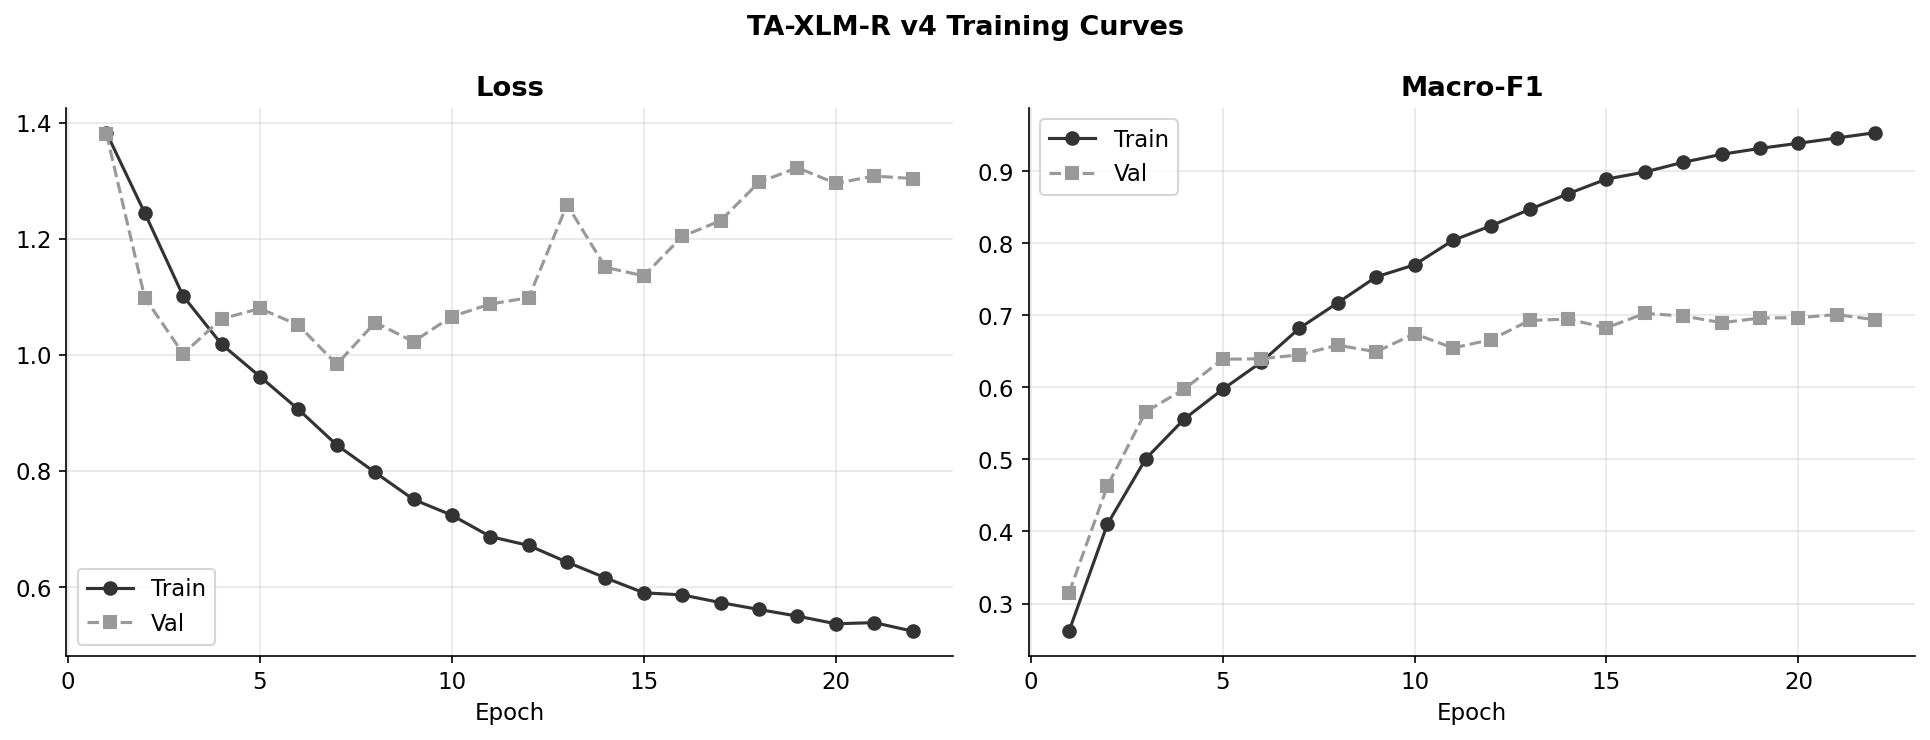

In [16]:
hist     = all_histories[best_seed_idx]
ep_range = range(1, len(hist['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tr_key, vl_key), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_f1', 'val_f1')],
    ['Loss', 'Macro-F1']
):
    ax.plot(ep_range, hist[tr_key], '-o', color='0.2', label='Train', linewidth=1.5)
    ax.plot(ep_range, hist[vl_key], '--s', color='0.6', label='Val', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle(f'TA-XLM-R v4 Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_v4.png', bbox_inches='tight')
plt.show()

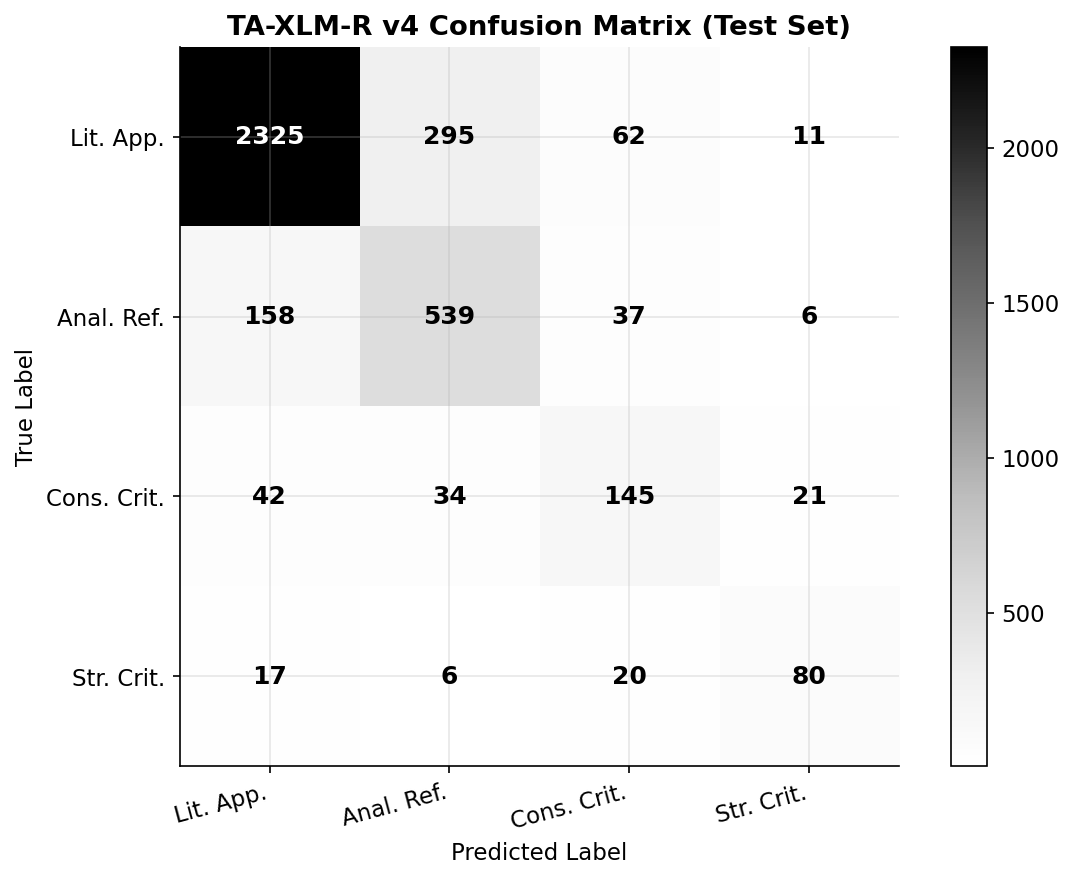

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Greys')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(SHORT_LBL, rotation=15, ha='right')
ax.set_yticklabels(SHORT_LBL)

thresh = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_title('TA-XLM-R v4 Confusion Matrix (Test Set)', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_v4.png', bbox_inches='tight')
plt.show()

## 13. Save Artifacts

In [18]:
# ============================================================================
# CELL 31 (corrected) — Save Artifacts
# ============================================================================
#
# FIX: After saving, immediately reload the checkpoint from disk into a
# fresh model and re-run inference on the test set, then compare against
# the saved .npy predictions. This is the check that would have caught
# the 54% mismatch before it ever left the notebook.

torch.save(best_model_state, 'ta_xlmr_v4_best.pt')

with open('char_vocab_v4.json', 'w', encoding='utf-8') as f:
    json.dump(CHAR_VOCAB, f, ensure_ascii=False, indent=2)

np.save('y_true_xlmr.npy', np.array(best_y_true))
np.save('y_pred_xlmr.npy', np.array(best_y_pred))
print(f"✅ Predictions saved | best seed: {CFG['seeds'][best_seed_idx]} | "
      f"model: {best_model_kind} | Macro-F1: {best_seed_f1:.4f}")

summary = {
    'model'       : 'TA-XLM-R v4',
    'best_model_kind': best_model_kind,
    'improvements': [
        'Mean-pool + CLS fusion',
        'Char CNN (multi-scale 2,3,4-gram)',
        'Cross-modal attention fusion',
        'Differential LR (4 groups)',
        'Gradient accumulation (eff. batch=64)',
        'Mixup augmentation in embedding space',
        'SWA (Stochastic Weight Averaging) — selected on val set only',
        'Expanded transliteration map (+20 entries)',
        'max_len=160, warmup=15%',
    ],
    'seeds'       : CFG['seeds'],
    'mean_metrics': {k: round(agg[k]['mean'], 4) for k in metrics_keys},
    'std_metrics' : {k: round(agg[k]['std'],  4) for k in metrics_keys},
    'target_met'  : bool(agg['macro_f1']['mean'] > 0.75),
}
with open('results_summary_v4.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved: ta_xlmr_v4_best.pt | char_vocab_v4.json | results_summary_v4.json')
print(f'\n  Final mean Macro-F1: {agg["macro_f1"]["mean"]:.4f} ± {agg["macro_f1"]["std"]:.4f}')
print(f'  Target >0.75 met: {"✅" if summary["target_met"] else "❌"}')

# ── FINAL VERIFICATION: reload from disk and confirm match ─────────────────
print('\n' + '='*60)
print('  FINAL VERIFICATION — reload ta_xlmr_v4_best.pt from disk')
print('='*60)

_verify_model = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
_state = torch.load('ta_xlmr_v4_best.pt', map_location=DEVICE)
_verify_model.load_state_dict(_state)

_, _, _, _v_true, _v_pred = run_epoch(_verify_model, best_tel, best_criterion)
_v_metrics = compute_all_metrics(_v_true, _v_pred)

_saved_true = np.load('y_true_xlmr.npy')
_saved_pred = np.load('y_pred_xlmr.npy')
_saved_metrics = compute_all_metrics(_saved_true, _saved_pred)

print(f'  Reloaded .pt  -> Acc: {_v_metrics["accuracy"]:.4f}  '
      f'Macro-F1: {_v_metrics["macro_f1"]:.4f}')
print(f'  Saved .npy    -> Acc: {_saved_metrics["accuracy"]:.4f}  '
      f'Macro-F1: {_saved_metrics["macro_f1"]:.4f}')

if abs(_v_metrics['accuracy'] - _saved_metrics['accuracy']) < 1e-6:
    print('  ✅ Checkpoint and saved predictions MATCH.')
else:
    print('  ❌ MISMATCH — checkpoint does NOT correspond to saved .npy '
          'predictions. Do not distribute these artifacts.')

del _verify_model, _state

✅ Predictions saved | best seed: 7 | model: base | Macro-F1: 0.6983
Saved: ta_xlmr_v4_best.pt | char_vocab_v4.json | results_summary_v4.json

  Final mean Macro-F1: 0.6881 ± 0.0134
  Target >0.75 met: ❌

  FINAL VERIFICATION — reload ta_xlmr_v4_best.pt from disk


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Reloaded .pt  -> Acc: 0.8133  Macro-F1: 0.6983
  Saved .npy    -> Acc: 0.8133  Macro-F1: 0.6983
  ✅ Checkpoint and saved predictions MATCH.
